**IMPLEMENTASI TEXT MINING BERBASIS NLP UNTUK ANALISIS POLA KEGIATAN MAGANG STUDI INDEPENDEN VINIX7 BATCH 4**

NAMA: SAFIRA KHALISHA

NIM : 230170175



**1. Install dan Import Library**


In [1]:
!pip install python-docx PySastrawi scikit-learn gensim matplotlib seaborn wordcloud -q

import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from docx import Document
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from gensim import corpora
from gensim.models import LdaModel
from wordcloud import WordCloud
from google.colab import files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.2 MB/s eta 0:00:00


**2. Load Dataset**

In [2]:
from google.colab import files
import pandas as pd

print("Upload file logbook_bersih.csv")
uploaded = files.upload()

df = pd.read_csv("logbook_bersih.csv")

# Filter hanya minggu 1-10 (sudah bersih tapi jaga-jaga)
df = df[df['minggu'].between(1, 10)].reset_index(drop=True)

print(f"Total data: {len(df)} entri")
print(df.groupby('nama')['minggu'].count())
df.head()

Upload file logbook_bersih.csv


Saving logbook_bersih.csv to logbook_bersih.csv
Total data: 166 entri
nama
Safira      66
Tri         50
Wardatul    50
Name: minggu, dtype: int64


,nama,minggu,hari_tanggal,deskripsi
0,Wardatul,1,Senin/23 Februari 2026,Mengikuti sesi Zoom onboarding yang diadakan t...
1,Wardatul,1,Selasa/24 Februari 2026,Melakukan perkenalan dengan anggota tim kelomp...
2,Wardatul,1,Rabu/25 Februari 2026,Mengikuti Zoom briefing bersama mitra untuk pe...
3,Wardatul,1,Kamis/26 Februari 2026,Mengikuti Zoom diskusi penugasan bersama mento...
4,Wardatul,1,Jumat/27 Februari 2026,Mengikuti Zoom pengarahan mengenai tata cara p...


**3. Preprocessing**

1.	Case folding
2.	Cleaning
3.	Tokenisasi
4.	Stopword removal
5.	Stemming

In [3]:
factory_stop = StopWordRemoverFactory()
factory_stem = StemmerFactory()
stopword_remover = factory_stop.create_stop_word_remover()
stemmer = factory_stem.create_stemmer()

# Tambah stopword custom sesuai konteks logbook
custom_stopwords = {
    'zoom', 'mengikuti', 'sesi', 'bersama', 'mitra', 'mentor',
    'magang', 'anggota', 'tim', 'tugas', 'modul', 'penugasan',
    'minggu', 'hari', 'kemudian', 'setelah', 'selanjutnya',
    'juga', 'saya', 'kami', 'yang', 'dan', 'dari', 'untuk',
    'dengan', 'pada', 'ke', 'di', 'ini', 'itu', 'briefing',
    'diskusi', 'membahas', 'teknis', 'pengerjaan', 'sudah',
    'belum', 'akan', 'telah', 'dapat', 'bisa', 'ada'
}

def preprocess(teks):
    teks = teks.lower()
    teks = re.sub(r'[^a-z\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    teks = stopword_remover.remove(teks)
    tokens = teks.split()
    tokens = [t for t in tokens if t not in custom_stopwords and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

df['teks_bersih'] = df['deskripsi'].apply(preprocess)
df['tokens'] = df['teks_bersih'].apply(lambda x: x.split())

print("Contoh hasil preprocessing:")
for i in range(3):
    print(f"\nAsli  : {df['deskripsi'][i][:80]}...")
    print(f"Bersih: {df['teks_bersih'][i]}")

Contoh hasil preprocessing:

Asli  : Mengikuti sesi Zoom onboarding yang diadakan tim koordinator magang. Kegiatan in...
Bersih: onboarding ada koordinator giat isi kenal arah umum alur divisi ekspektasi penuh jalan

Asli  : Melakukan perkenalan dengan anggota tim kelompok 14 secara daring. Diskusi ringa...
Bersih: kenal kelompok daring ringan proyek proyek

Asli  : Mengikuti Zoom briefing bersama mitra untuk penugasan modul 1 dan zoom mentorshi...
Bersih: mentorship bagi pakat tanggung load data cleaning


**4.  TF-IDF Vectorization**

Teks yang telah diproses diubah ke representasi numerik menggunakan TF-IDF (Term Frequency-Inverse Document Frequency) Vectorizer dari pustaka Scikit-learn.

In [4]:
tfidf = TfidfVectorizer(max_features=200, min_df=2, max_df=0.85, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['teks_bersih'])

print(f"Shape matrix TF-IDF: {X_tfidf.shape}")
print(f"Contoh fitur: {tfidf.get_feature_names_out()[:20]}")

Shape matrix TF-IDF: (166, 200)
Contoh fitur: ['ajar' 'ajar mandiri' 'algoritma' 'algoritma apriori' 'alur' 'analis'
 'analisis' 'apriori' 'arah' 'association' 'backorder' 'bagi' 'baik'
 'banding' 'bangun' 'bangun pipeline' 'base' 'base model' 'benchmarking'
 'bentuk']


**5. Task 1: K-Means Clustering**

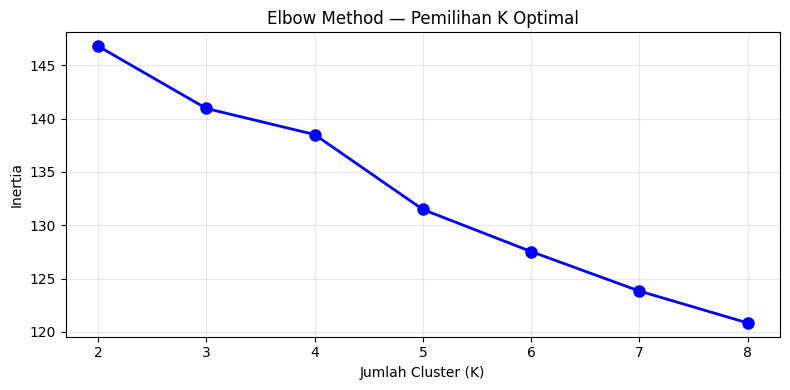


Top keywords per cluster:

Cluster 0: hasil, lapor, kumpul, sesuai, model, evaluasi, giat, susun, tentu, baik

Cluster 1: mandiri, ajar, mentorship ajar, ajar mandiri, mentorship, fungsi, data, coba, encoding, eksplorasi data

Cluster 2: pipeline, scikit learn, scikit, learn, bangun, regression, validation, cross, cross validation, model

Cluster 3: data, bagi, giat, lanjut, kait, model, proyek, diskus, arah, kelompok

Cluster 4: senin, senin jumat, susun logbook, logbook senin, jumat, logbook, tentu susun, sesuai tentu, susun, tentu


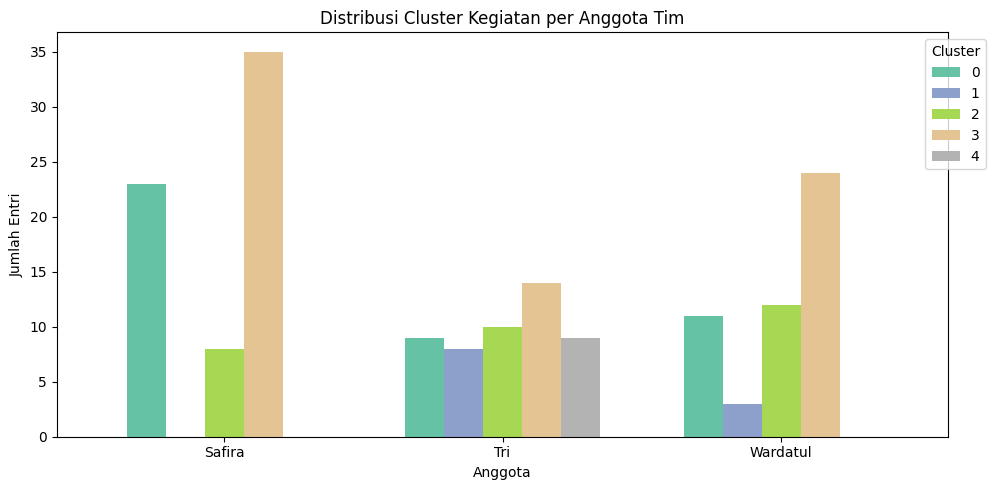

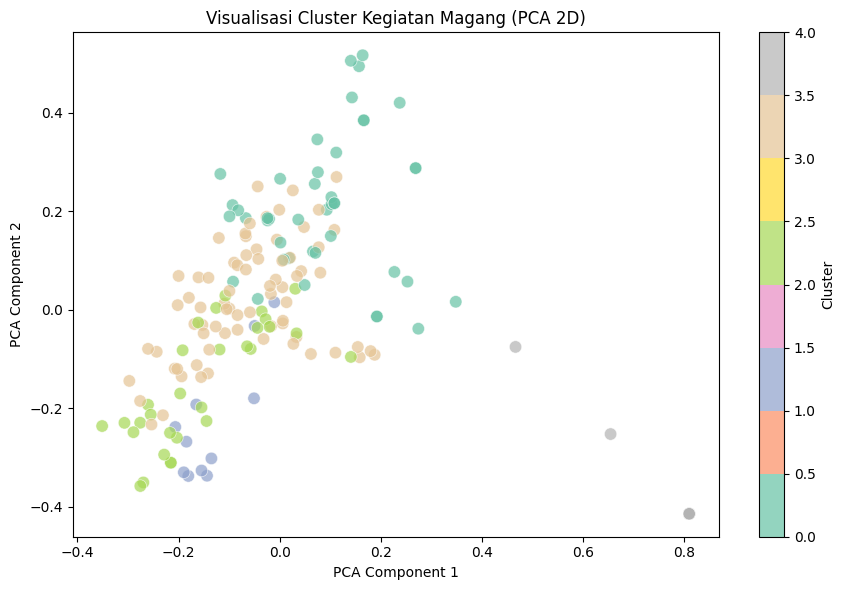

In [5]:
# Elbow method untuk cari K optimal
inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_tfidf)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Pemilihan K Optimal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Jalankan K-Means dengan K=5 (sesuaikan setelah lihat elbow)
K_OPTIMAL = 5
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_tfidf)

# Lihat top keywords per cluster
feature_names = tfidf.get_feature_names_out()
print("\nTop keywords per cluster:")
for i in range(K_OPTIMAL):
    center = kmeans.cluster_centers_[i]
    top_idx = center.argsort()[-10:][::-1]
    kata_kunci = [feature_names[j] for j in top_idx]
    print(f"\nCluster {i}: {', '.join(kata_kunci)}")

# Distribusi cluster per anggota
fig, ax = plt.subplots(figsize=(10, 5))
cluster_dist = df.groupby(['nama', 'cluster']).size().unstack(fill_value=0)
cluster_dist.plot(kind='bar', ax=ax, colormap='Set2', width=0.7)
ax.set_title('Distribusi Cluster Kegiatan per Anggota Tim')
ax.set_xlabel('Anggota')
ax.set_ylabel('Jumlah Entri')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Visualisasi scatter plot (PCA 2D)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_tfidf.toarray())
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                       c=df['cluster'], cmap='Set2',
                       alpha=0.7, s=80, edgecolors='white', linewidths=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualisasi Cluster Kegiatan Magang (PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

**6. Task 2: LDA Topic Modeling**

=== TOPIK YANG DITEMUKAN LDA ===

Topik 1: model | analisis | hasil | giat | pipeline | susun | fokus | bagi
Topik 2: data | pipeline | kelompok | learn | scikit | tentu | bangun | susun
Topik 3: giat | hasil | model | sesuai | kumpul | arah | data | evaluasi
Topik 4: feature | fokus | tentu | giat | google | data | scaling | pipeline
Topik 5: data | mentorship | decision | tree | mandiri | ajar | poin | random


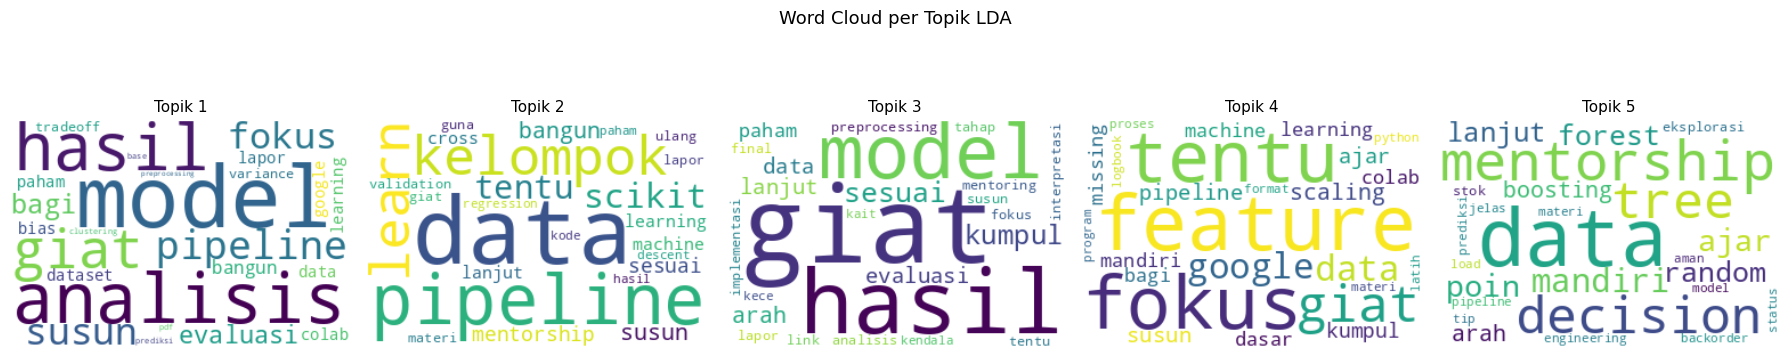

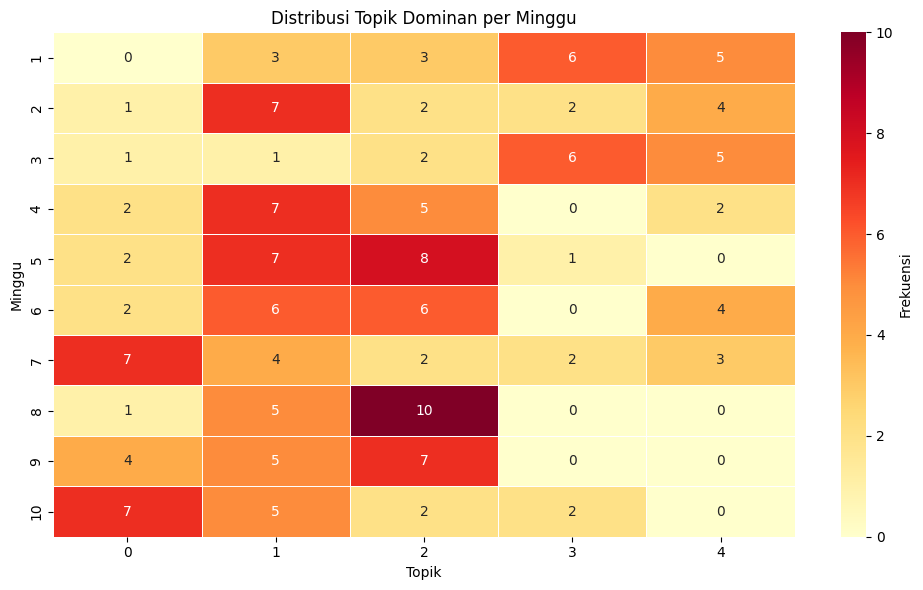

In [6]:
# Siapkan corpus untuk Gensim
dictionary = corpora.Dictionary(df['tokens'])
dictionary.filter_extremes(no_below=2, no_above=0.8)
corpus = [dictionary.doc2bow(tokens) for tokens in df['tokens']]

# Latih LDA
NUM_TOPICS = 5
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=15,
    alpha='auto',
    per_word_topics=True
)

# Tampilkan topik
print("=== TOPIK YANG DITEMUKAN LDA ===\n")
for idx, topik in lda_model.print_topics(num_words=8):
    kata = re.findall(r'"([^"]+)"', topik)
    print(f"Topik {idx+1}: {' | '.join(kata)}")

# Word cloud per topik
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(18, 4))
for i in range(NUM_TOPICS):
    words = dict(lda_model.show_topic(i, topn=30))
    wc = WordCloud(width=300, height=200, background_color='white',
                   colormap='viridis', max_words=25)
    wc.generate_from_frequencies(words)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Topik {i+1}', fontsize=11)
    axes[i].axis('off')
plt.suptitle('Word Cloud per Topik LDA', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Distribusi topik dominan per minggu per anggota
def topik_dominan(tokens):
    bow = dictionary.doc2bow(tokens)
    topik_dist = lda_model.get_document_topics(bow)
    if not topik_dist:
        return 0
    return max(topik_dist, key=lambda x: x[1])[0]

df['topik_dominan'] = df['tokens'].apply(topik_dominan)

# Heatmap topik per minggu
pivot = df.groupby(['minggu', 'topik_dominan']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Frekuensi'})
plt.title('Distribusi Topik Dominan per Minggu')
plt.xlabel('Topik')
plt.ylabel('Minggu')
plt.tight_layout()
plt.show()

** 7. Task 3: Cosine Similarity Antar Anggota**

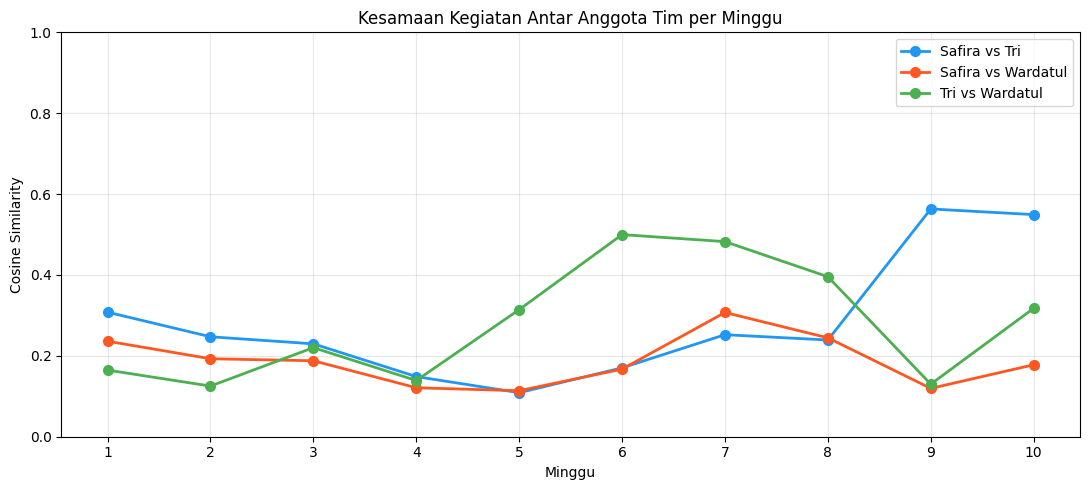

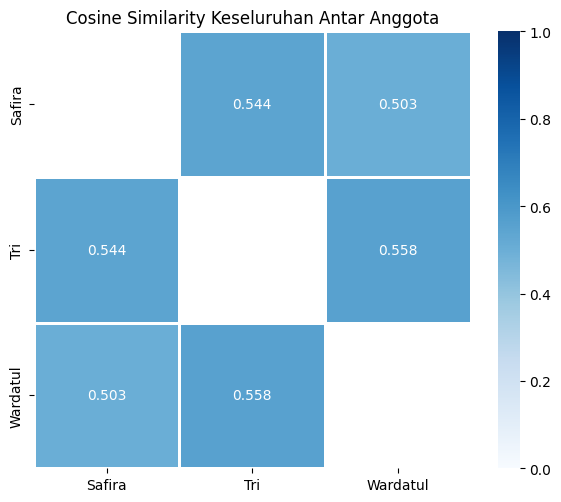


Rata-rata similarity per pasangan:
  Safira vs Tri: 0.2817
  Safira vs Wardatul: 0.1868
  Tri vs Wardatul: 0.2789


In [7]:
# Gabung semua teks per anggota per minggu
df_minggu = df.groupby(['nama', 'minggu'])['teks_bersih'].apply(' '.join).reset_index()

# Pivot: baris = minggu, kolom = anggota
pivot_teks = df_minggu.pivot(index='minggu', columns='nama', values='teks_bersih').fillna('')

nama_list = pivot_teks.columns.tolist()
tfidf2 = TfidfVectorizer(max_features=300)

# Similarity per minggu
similarities_per_minggu = {comb: [] for comb in [
    f"{nama_list[i]} vs {nama_list[j]}"
    for i in range(len(nama_list))
    for j in range(i+1, len(nama_list))
]}

minggu_list = pivot_teks.index.tolist()

for minggu in minggu_list:
    baris = pivot_teks.loc[minggu]
    try:
        vectors = tfidf2.fit_transform(baris.values)
        sim_matrix = cosine_similarity(vectors)
        k = 0
        for i in range(len(nama_list)):
            for j in range(i+1, len(nama_list)):
                key = f"{nama_list[i]} vs {nama_list[j]}"
                similarities_per_minggu[key].append(sim_matrix[i][j])
    except:
        for key in similarities_per_minggu:
            similarities_per_minggu[key].append(0)

# Plot similarity per minggu
plt.figure(figsize=(11, 5))
colors = ['#2196F3', '#FF5722', '#4CAF50']
for idx, (label, vals) in enumerate(similarities_per_minggu.items()):
    plt.plot(minggu_list, vals, 'o-', label=label,
             color=colors[idx], linewidth=2, markersize=7)
plt.xlabel('Minggu')
plt.ylabel('Cosine Similarity')
plt.title('Kesamaan Kegiatan Antar Anggota Tim per Minggu')
plt.xticks(minggu_list)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Heatmap similarity keseluruhan
all_texts = [' '.join(df[df['nama'] == n]['teks_bersih']) for n in nama_list]
tfidf3 = TfidfVectorizer(max_features=300)
X_all = tfidf3.fit_transform(all_texts)
sim_overall = cosine_similarity(X_all)

plt.figure(figsize=(6, 5))
mask = np.zeros_like(sim_overall, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(sim_overall, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=nama_list, yticklabels=nama_list,
            vmin=0, vmax=1, linewidths=1,
            mask=mask, square=True)
plt.title('Cosine Similarity Keseluruhan Antar Anggota')
plt.tight_layout()
plt.show()

print("\nRata-rata similarity per pasangan:")
for label, vals in similarities_per_minggu.items():
    print(f"  {label}: {np.mean(vals):.4f}")

**KESIMPULAN HASIL**

In [8]:
print("=" * 55)
print("RINGKASAN ANALISIS NLP LOGBOOK MAGANG VINIX7")
print("=" * 55)

print(f"\nTotal entri dianalisis : {len(df)}")
for nama in df['nama'].unique():
    jumlah = len(df[df['nama'] == nama])
    print(f"  {nama}: {jumlah} entri (minggu 1-10)")

print(f"\n[Task 1 - K-Means] Kegiatan terbagi {K_OPTIMAL} cluster")
for i in range(K_OPTIMAL):
    n = len(df[df['cluster'] == i])
    pct = n / len(df) * 100
    print(f"  Cluster {i}: {n} entri ({pct:.1f}%)")

print(f"\n[Task 2 - LDA] {NUM_TOPICS} topik dominan ditemukan")
for idx, topik in lda_model.print_topics(num_words=5):
    kata = re.findall(r'"([^"]+)"', topik)
    print(f"  Topik {idx+1}: {', '.join(kata[:4])}")

print(f"\n[Task 3 - Cosine Similarity] Kesamaan antar anggota:")
for label, vals in similarities_per_minggu.items():
    print(f"  {label}: rata-rata {np.mean(vals):.4f}")

print("\nKesimpulan:")
max_sim = max(similarities_per_minggu.items(), key=lambda x: np.mean(x[1]))
print(f"  Pasangan paling mirip pola kerjanya: {max_sim[0]}")
print(f"  (similarity = {np.mean(max_sim[1]):.4f})")

RINGKASAN ANALISIS NLP LOGBOOK MAGANG VINIX7

Total entri dianalisis : 166
  Wardatul: 50 entri (minggu 1-10)
  Safira: 66 entri (minggu 1-10)
  Tri: 50 entri (minggu 1-10)

[Task 1 - K-Means] Kegiatan terbagi 5 cluster
  Cluster 0: 43 entri (25.9%)
  Cluster 1: 11 entri (6.6%)
  Cluster 2: 30 entri (18.1%)
  Cluster 3: 73 entri (44.0%)
  Cluster 4: 9 entri (5.4%)

[Task 2 - LDA] 5 topik dominan ditemukan
  Topik 1: model, analisis, hasil, giat
  Topik 2: data, pipeline, kelompok, learn
  Topik 3: giat, hasil, model, sesuai
  Topik 4: feature, fokus, tentu, giat
  Topik 5: data, mentorship, decision, tree

[Task 3 - Cosine Similarity] Kesamaan antar anggota:
  Safira vs Tri: rata-rata 0.2817
  Safira vs Wardatul: rata-rata 0.1868
  Tri vs Wardatul: rata-rata 0.2789

Kesimpulan:
  Pasangan paling mirip pola kerjanya: Safira vs Tri
  (similarity = 0.2817)


In [9]:
import os

# ── 1. Simpan DataFrame ──────────────────────────────────────
df[['nama', 'minggu', 'hari_tanggal', 'deskripsi', 'teks_bersih', 'cluster', 'topik_dominan']]\
  .to_csv('hasil_preprocessing.csv', index=False)

df_cluster = df[['nama', 'minggu', 'hari_tanggal', 'deskripsi', 'cluster']].copy()
df_cluster['label_cluster'] = df_cluster['cluster'].map({
    0: 'Pengerjaan Tugas Teknis',
    1: 'Evaluasi & Finalisasi',
    2: 'Briefing & Mentorship',
    3: 'Diskusi Tim & Kolaborasi',
    4: 'Pembelajaran Mandiri'
})
df_cluster.to_csv('hasil_clustering.csv', index=False)

df_topik = df[['nama', 'minggu', 'hari_tanggal', 'deskripsi', 'topik_dominan']].copy()
df_topik.to_csv('hasil_topik_lda.csv', index=False)

ringkasan_cluster = df.groupby(['nama', 'cluster']).size().unstack(fill_value=0)
ringkasan_cluster.to_csv('ringkasan_cluster_per_anggota.csv')

ringkasan_topik = df.groupby(['minggu', 'topik_dominan']).size().unstack(fill_value=0)
ringkasan_topik.to_csv('ringkasan_topik_per_minggu.csv')

sim_df = pd.DataFrame([
    {'pasangan': label, 'rata_rata_similarity': round(float(np.mean(vals)), 4)}
    for label, vals in similarities_per_minggu.items()
])
sim_df.to_csv('hasil_cosine_similarity.csv', index=False)

# ── 2. Simpan semua gambar ───────────────────────────────────

# Elbow Method
inertia2 = []
for k in range(2, 9):
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X_tfidf)
    inertia2.append(km_tmp.inertia_)
plt.figure(figsize=(8, 4))
plt.plot(list(range(2, 9)), inertia2, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Pemilihan K Optimal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.close()

# Distribusi cluster per anggota
fig, ax = plt.subplots(figsize=(10, 5))
cluster_dist2 = df.groupby(['nama', 'cluster']).size().unstack(fill_value=0)
cluster_dist2.plot(kind='bar', ax=ax, colormap='Set2', width=0.7)
ax.set_title('Distribusi Cluster Kegiatan per Anggota Tim')
ax.set_xlabel('Anggota')
ax.set_ylabel('Jumlah Entri')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('distribusi_cluster.png', dpi=150)
plt.close()

# PCA Scatter
pca2 = PCA(n_components=2, random_state=42)
X_2d2 = pca2.fit_transform(X_tfidf.toarray())
plt.figure(figsize=(9, 6))
sc = plt.scatter(X_2d2[:, 0], X_2d2[:, 1],
                 c=df['cluster'], cmap='Set2',
                 alpha=0.7, s=80, edgecolors='white', linewidths=0.5)
plt.colorbar(sc, label='Cluster')
plt.title('Visualisasi Cluster Kegiatan Magang (PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.savefig('pca_cluster.png', dpi=150)
plt.close()

# Word cloud per topik LDA
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(18, 4))
for i in range(NUM_TOPICS):
    words = dict(lda_model.show_topic(i, topn=30))
    wc = WordCloud(width=300, height=200, background_color='white',
                   colormap='viridis', max_words=25)
    wc.generate_from_frequencies(words)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Topik {i+1}', fontsize=11)
    axes[i].axis('off')
plt.suptitle('Word Cloud per Topik LDA', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('wordcloud_topik.png', dpi=150, bbox_inches='tight')
plt.close()

# Heatmap topik per minggu
pivot2 = df.groupby(['minggu', 'topik_dominan']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot2, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Frekuensi'})
plt.title('Distribusi Topik Dominan per Minggu')
plt.xlabel('Topik')
plt.ylabel('Minggu')
plt.tight_layout()
plt.savefig('heatmap_topik.png', dpi=150)
plt.close()

# Cosine Similarity per minggu
plt.figure(figsize=(11, 5))
colors = ['#2196F3', '#FF5722', '#4CAF50']
for idx, (label, vals) in enumerate(similarities_per_minggu.items()):
    plt.plot(minggu_list, vals, 'o-', label=label,
             color=colors[idx], linewidth=2, markersize=7)
plt.xlabel('Minggu')
plt.ylabel('Cosine Similarity')
plt.title('Kesamaan Kegiatan Antar Anggota Tim per Minggu')
plt.xticks(minggu_list)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cosine_similarity_perminggu.png', dpi=150)
plt.close()

# Heatmap cosine similarity keseluruhan
all_texts2 = [' '.join(df[df['nama'] == n]['teks_bersih']) for n in nama_list]
tfidf4 = TfidfVectorizer(max_features=300)
X_all2 = tfidf4.fit_transform(all_texts2)
sim_overall2 = cosine_similarity(X_all2)
plt.figure(figsize=(6, 5))
mask2 = np.zeros_like(sim_overall2, dtype=bool)
np.fill_diagonal(mask2, True)
sns.heatmap(sim_overall2, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=nama_list, yticklabels=nama_list,
            vmin=0, vmax=1, linewidths=1, mask=mask2, square=True)
plt.title('Cosine Similarity Keseluruhan Antar Anggota')
plt.tight_layout()
plt.savefig('heatmap_cosine_overall.png', dpi=150)
plt.close()

# ── 3. Cetak daftar output ───────────────────────────────────
outputs = [
    'logbook_bersih.csv',
    'hasil_preprocessing.csv',
    'hasil_clustering.csv',
    'hasil_topik_lda.csv',
    'ringkasan_cluster_per_anggota.csv',
    'ringkasan_topik_per_minggu.csv',
    'hasil_cosine_similarity.csv',
    'elbow_method.png',
    'distribusi_cluster.png',
    'pca_cluster.png',
    'wordcloud_topik.png',
    'heatmap_topik.png',
    'cosine_similarity_perminggu.png',
    'heatmap_cosine_overall.png',
]

print('=' * 50)
print('OUTPUT TERSIMPAN:')
print('=' * 50)
for f in outputs:
    status = '✓' if os.path.exists(f) else '✗ BELUM ADA'
    print(f'  {status}  {f}')

OUTPUT TERSIMPAN:
  ✓  logbook_bersih.csv
  ✓  hasil_preprocessing.csv
  ✓  hasil_clustering.csv
  ✓  hasil_topik_lda.csv
  ✓  ringkasan_cluster_per_anggota.csv
  ✓  ringkasan_topik_per_minggu.csv
  ✓  hasil_cosine_similarity.csv
  ✓  elbow_method.png
  ✓  distribusi_cluster.png
  ✓  pca_cluster.png
  ✓  wordcloud_topik.png
  ✓  heatmap_topik.png
  ✓  cosine_similarity_perminggu.png
  ✓  heatmap_cosine_overall.png

Upload semua file + notebook ini ke GitHub!
Salin link repo dan tempelkan di laporan bagian Abstrak.
